In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot
from utils.problem_setup import TestProblemsSetup
from utils.utils import disk_cache

from utils.colors import CMAP
from utils.plotting import save_plot
import matplotlib.patches as patches

from algorithms.cg_solvers import DynamicalLowRankPCG
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})


SETUP = TestProblemsSetup(n=64)
PROBLEM_PARAMS = SETUP.problem_params
PROBLEMS = SETUP.get_test_problems()
SEED = 15

In [120]:
def as_func(x, V_h):
    f = Function(V_h)
    f.vector()[:] = x
    return f


def plot_multiple_f(solutions, pid, labels=None, fig_name=None, shrink=0.3, outline_truth=True, colorbar=False):
    pb = PROBLEMS[pid]
    PARAMS = PROBLEM_PARAMS[pid]
    f_list = [as_func(x, pb['V_h']) for x in solutions]

    width, height = PARAMS['width'], PARAMS['height']
    x0s, y0s = PARAMS['x0'], PARAMS['y0']

    fig, axes = plt.subplots(1, len(f_list), figsize=(9, 6.06), constrained_layout=True)

    if labels is None: labels = ['' for _ in axes.flat]

    for ax, func, label in zip(axes.flat, f_list, labels):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, cmap=CMAP)
        if colorbar: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(label, labelpad=10)

        if outline_truth:
            for x0, y0 in zip(x0s, y0s):
                square = patches.Rectangle(
                    (x0, y0), width, height,
                    edgecolor="white",
                    facecolor="none"
                )
                ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()


---
**Trying different preconditioners**


In [121]:

def experiment(param_grid, default_args, pid, k=50):
    pb = PROBLEMS[pid]
    rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=k, seed=SEED)
    w = rsvd.weights()

    errors, solutions, residuals = [], [], []
    
    for params in param_grid:
        solver = DynamicalLowRankPCG(rsvd, pb['x'])
        x = solver.solve(pb['y'], w, **default_args, **params, seed=SEED)
        
        errors.append(solver.error.copy())
        residuals.append(solver.residual.copy())
        solutions.append(x)

    return {'solutions': solutions, 'errors': errors, 'residuals': residuals}

In [122]:
param_grid = [
    {'preconditioner': 'none',        'max_iter': 500},
    {'preconditioner': 'jacobi',      'max_iter': 500},
    {'preconditioner': 'ic',          'max_iter': 500},
    {'preconditioner': 'ic-woodbury', 'max_iter': 3},
    {'preconditioner': 'perfect',     'max_iter': 2},
]

default_args = {'lambda_': 1e-4, 'max_rank': 1, 'rtol': 0, 'etol': 0}
resultsI = experiment(param_grid, default_args, pid='I')

default_args = {'lambda_': 1e-4, 'max_rank': 2, 'rtol': 0, 'etol': 0}
resultsII = experiment(param_grid, default_args, pid='II')

[##############################] 500/500
[##############################] 500/500
[##############################] 500/500
[##############################] 3/3
[##############################] 2/2
[##############################] 500/500
[##############################] 500/500
[##############################] 500/500
[##############################] 3/3
[##############################] 2/2


In [124]:
for e, p in zip(resultsI['errors'], param_grid):
    print(p['preconditioner'], e[-1])

none 0.8112147446759227
jacobi 0.8063830191941037
ic 0.857058962293711
ic-woodbury 0.8366549648092572
perfect 0.8364926817920921


../../figures/number_of_iterations_preconditioners.png already exists


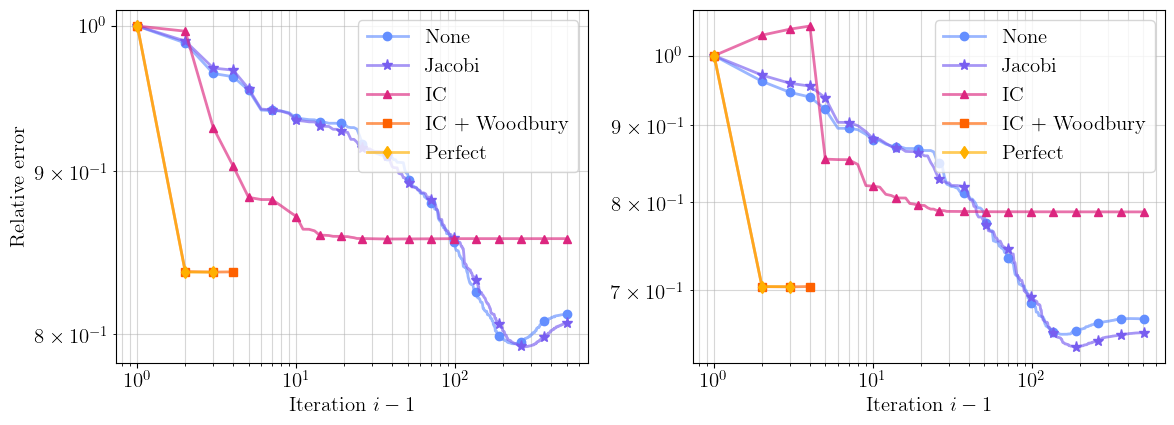

In [110]:
def plot_errors(e_list, names=None, fig_name=None, n_marks=20, ax=None, ylim=None, ylabel=True):
    from utils.colors import C5, M, MS
    from utils.plotting import save_plot
    from matplotlib.lines import Line2D

    if ax is None: fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    else: fig = ax.figure
    if names is None: names = ['' for _ in e_list]

    for i, e in enumerate(e_list):
        x = np.arange(1, len(e) + 1)

        x_marks = np.logspace(np.log10(x[0]), np.log10(x[-1]), n_marks)
        mark_idx = np.unique([np.abs(x - xm).argmin() for xm in x_marks])

        ax.loglog(x, e, lw=2.0, label=names[i], markevery=mark_idx, c=C5[i], alpha=.65)
        ax.loglog(x, e, M[i], lw=2.0, markevery=mark_idx, ms=MS[i], c=C5[i])

    if ylim is not None: ax.set_ylim(ylim)

    handles, labels = [], names
    for i in range(len(e_list)):
        legend_line = Line2D([0], [0], color=C5[i], linewidth=2.0, alpha=.65)
        legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    if ylabel: ax.set_ylabel('Relative error')
    ax.set_xlabel('Iteration $i - 1$')
    ax.grid(True, which='both', alpha=.5)
    ax.legend(handles=handles, labels=labels, loc='upper right')

    if fig_name is not None:
        save_plot(fig_name)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

names = ['None', 'Jacobi', 'IC', 'IC + Woodbury', 'Perfect']
plot_errors(resultsI['errors'],  names=names, ax=axes[0])
plot_errors(resultsII['errors'], names=names, ax=axes[1], ylabel=False)

plt.tight_layout()
save_plot('number_of_iterations_preconditioners')
plt.show()

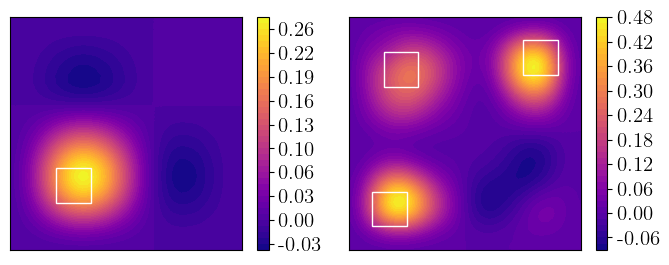

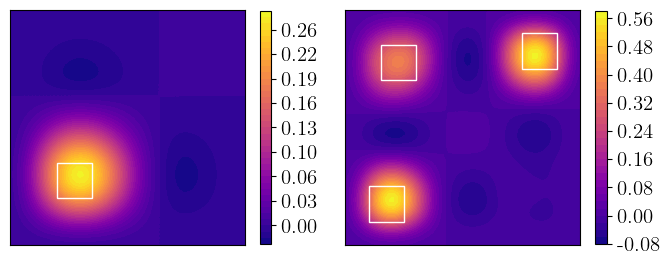

In [116]:
ic_solutions = [resultsI['solutions'][2], resultsII['solutions'][2]]
perfect_solutions = [resultsI['solutions'][4], resultsII['solutions'][4]]

def plot_multiple_f2(
        x_list, fig_name=None, shrink=0,
    ):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches
    pb = PROBLEMS['I']

    f_list = []
    for x in x_list:
        f = Function(pb['V_h'])
        f.vector()[:] = x
        f_list.append(f)

    fig, axes = plt.subplots(1, 2, figsize=(7,4))
    
    for ax, func, pid in zip(axes.flat, f_list, ('I', 'II')):
        plt.sca(ax)
        p = plot(func, cmap=CMAP)
        if shrink != 0: fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        PBP = PROBLEM_PARAMS[pid]
        width, height = PBP['width'], PBP['height']
        x0s, y0s = PBP['x0'], PBP['y0']
        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)
    
    plt.tight_layout()
    save_plot(fig_name=fig_name)
    plt.show()

# Solutions which didn't converge well
plot_multiple_f2(ic_solutions, shrink=0.655, fig_name='low_rank_ic')
plot_multiple_f2(perfect_solutions, shrink=0.655, fig_name='low_rank_perfect')

---
**Using restarting together with DLRA-PCG**

In [78]:
param_grid = [
    {'restart_every': 2},
    {'restart_every': 5},
    {'restart_every': 10},
    {'restart_every': 25},
]
names_restart = [f"$N_r={p['restart_every']}$" for p in param_grid]

default_args = {'lambda_': 1e-4, 'max_rank': 2, 'rtol': 0, 'etol': 0, 'preconditioner': 'ic-woodbury', 'max_iter': 500}
results_diverge = experiment(param_grid, default_args, pid='II')

[##############################] 500/500
[##############################] 500/500
[##############################] 500/500
[##############################] 500/500


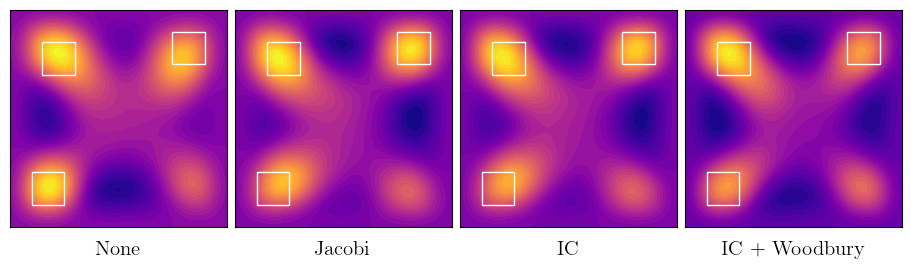

In [82]:
plot_multiple_f(results_diverge['solutions'], pid='II', labels=labels)

In [72]:
# Save this "bad" solution
x_bad = results_diverge['solutions'][0].copy()
pb = PROBLEMS['II']; rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50)
solver = DynamicalLowRankPCG(rsvd, pb['x'])
X_bad = solver.vec_to_matrix(x_bad)

# Use the "bad" starting point
param_grid = [
    {'preconditioner': 'none',        'max_iter': 500},
    {'preconditioner': 'jacobi',      'max_iter': 500},
    {'preconditioner': 'ic',          'max_iter': 500},
    {'preconditioner': 'ic-woodbury', 'max_iter': 10},
    {'preconditioner': 'perfect',     'max_iter': 2},
]

default_args = {'lambda_': 1e-4, 'max_rank': 2, 'rtol': 0, 'etol': 0, 'X0': X_bad}
results_diverge_2 = experiment(param_grid, default_args, pid='II')

[##############################] 500/500
[##############################] 500/500
[##############################] 500/500
[##############################] 10/10
[##############################] 2/2


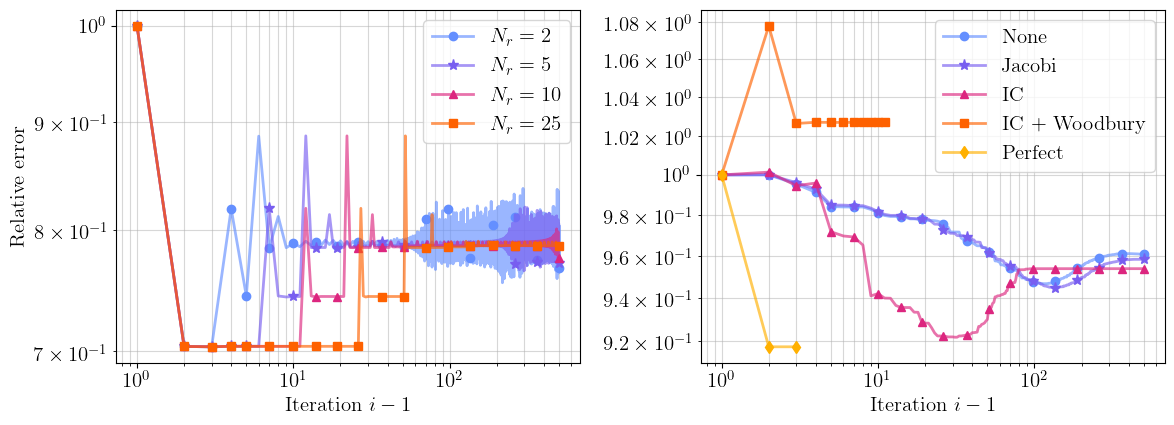

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

plot_errors(results_diverge['errors'],  names=names_restart, ax=axes[0])
plot_errors(results_diverge_2['errors'], names=names, ax=axes[1], ylabel=False)

plt.tight_layout()
save_plot('low_rank_local_minima')
plt.show()

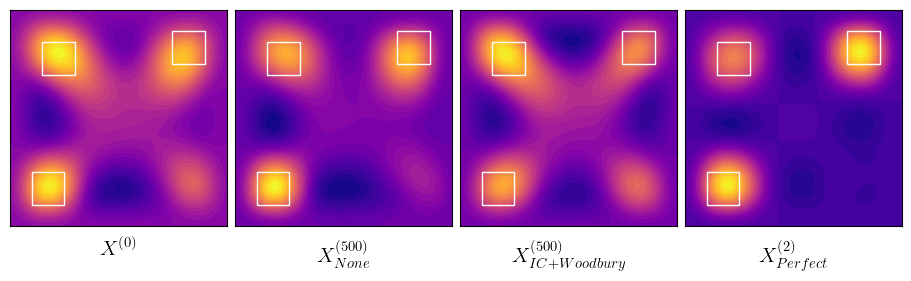

In [107]:
L_x = results_diverge_2['solutions']  # [None, Jacobi, IC, ICW, Perfect]
selected = [x_bad] + [L_x[0]] + [L_x[3]] + [L_x[4]]


plot_multiple_f(
    selected, pid='II',
    labels=['$X^{(0)}$', '$X^{(500)}_{None}$', '$X^{(500)}_{IC + Woodbury}$', '$X^{(2)}_{Perfect}$'],
    fig_name='low_rank_local_minima_solutions'
)

[##############################] 1/1
[##############################] 2/2
[##############################] 3/3
[##############################] 4/4


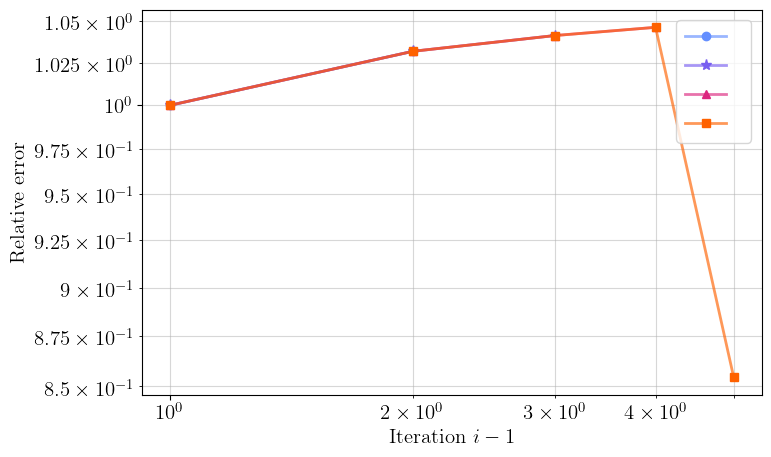

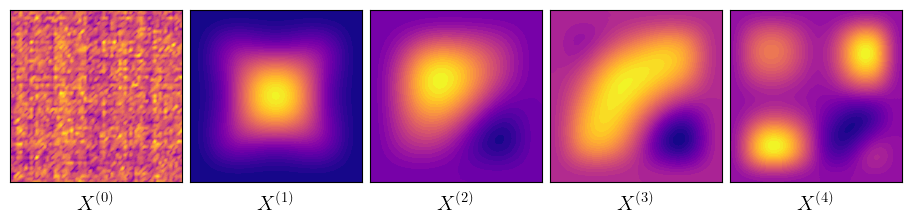

In [118]:
pb = PROBLEMS['II']
rsvd = MatrixFreeRSVD(pb['V_h']); rsvd.solve(k=50, seed=SEED)
w = rsvd.weights()

solver = DynamicalLowRankPCG(rsvd, pb['x'])
X0, *_ = solver.initial_X(seed=SEED, max_rank=2, X0='qr')
x0 = solver.matrix_to_vec(X0)


precond = 'ic'
param_grid = [
    {'preconditioner': precond, 'max_iter': 1},
    {'preconditioner': precond, 'max_iter': 2},
    {'preconditioner': precond, 'max_iter': 3},
    {'preconditioner': precond, 'max_iter': 4},
]

default_args = {'lambda_': 1e-4, 'max_rank': 2, 'rtol': 0, 'etol': 0}
results = experiment(param_grid, default_args, pid='II')
results['solutions'].insert(0, x0)

plot_errors(results['errors'])
plot_multiple_f(
    results['solutions'],
    pid='II', outline_truth=False,
    labels=[f'$X^{{({i})}}$' for i in range(1 + len(results['errors']))],
    fig_name='low_rank_ic_first_iters'
)

---
**Comparing with truncated SVD**

In [ ]:
# DO LATER (MAYBE)